# Loading your LCA model with temporal distributions from an excel file


This notebook is essentially a short version of the [example_electric_vehicle_standalone](./example_electric_vehicle_standalone.ipynb) example notebook, but shows how to import the foreground model from an [excel file](./data/example_electric_vehicle_standalone.xlsx). For a more detailed explaination of how timex works, please see one of the other notebooks. 


In [ ]:
# Set up a bw project

import bw2data as bd

bd.projects.set_current("electric_vehicle_standalone_excel")

In [ ]:
# Fresh start
for db in list(bd.databases):
    del bd.databases[db]

In [ ]:
# Add some background databases

biosphere = bd.Database("biosphere")
biosphere.register()
biosphere.write(
    {
        ("biosphere", "CO2"): {
            "type": "emission",
            "name": "carbon dioxide",
        },
    }
)

background_2020 = bd.Database("background_2020")
background_2020.register()

background_2030 = bd.Database("background_2030")
background_2030.register()

background_2040 = bd.Database("background_2040")
background_2040.register()

background_2020.write({})
background_2030.write({})
background_2040.write({})

background_databases = [
    background_2020,
    background_2030,
    background_2040,
]

100%|██████████| 1/1 [00:00<00:00, 7256.58it/s]

17:01:00+0200 [info     ] Vacuuming database            


We now create some very simple processes within these databases. These process get only one aggregated CO2-emission each. The amounts of these emissions change over time.

In [4]:
process_co2_emissions = {
    "glider": (10, 5, 2.5), # for 2020, 2030 and 2040
    "powertrain": (20, 10, 7.5),
    "battery": (10, 5, 4),
    "electricity": (0.5, 0.25, 0.075),
    "glider_eol": (0.01, 0.0075, 0.005),
    "powertrain_eol": (0.01, 0.0075, 0.005),
    "battery_eol": (1, 0.5, 0.25),
}

node_co2 = biosphere.get("CO2")

for component_name, gwis in process_co2_emissions.items():
    for database, gwi in zip(background_databases, gwis):
        database.new_node(component_name, name=component_name, location="somewhere").save()
        component = database.get(component_name)
        component["reference product"] = component_name        
        component.save()
        production_amount = -1 if "eol" in component_name else 1
        component.new_edge(input=component, amount=production_amount, type="production").save()
        component.new_edge(input=node_co2, amount=gwi, type="biosphere").save()

# register the databases
for db in bd.databases:
    bd.Database(db).process()   
    

## Case study setup


In this study, we consider the following production system for our ev. Purple boxes are foreground, cyan boxes are background (i.e., ecoinvent/premise).

```{mermaid}
flowchart LR
    glider_production(glider production):::ei-->ev_production
    powertrain_production(powertrain production):::ei-->ev_production
    battery_production(battery production):::ei-->ev_production
    ev_production(ev production):::fg-->driving
    electricity_generation(electricity generation):::ei-->driving
    driving(driving):::fg-->used_ev
    used_ev(used ev):::fg-->glider_eol(glider eol):::ei
    used_ev-->powertrain_eol(powertrain eol):::ei
    used_ev-->battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

### Importing the product system from Excel

As an alternative to generating your temporal foreground system in code as above, you can also import the case study processes from a BW25-excel file.
You need `bw2io > 0.9.14`, which supports the import of `TemporalDistributions` in the ExcelImporter or CSVImporter. You can consult the sample excel file under notebooks/data for valid input formats for the TDs.

Please make sure you created and processed the biosphere and the background databases for 2020, 2030 and 2040 using the code above.

In [5]:
if "foreground" in bd.databases:
    del bd.databases["foreground"] # to make sure we import the foreground from scratch from the excel file

import bw2io as bi

ei = bi.ExcelImporter("data/example_electric_vehicle_standalone.xlsx", sheet_name="easy_tds") 
ei.apply_strategies()
ei.match_database("background_2020",  fields=["name", "reference product"])
ei.match_database("biosphere", fields=["name", "categories"])

ei.statistics() #0 unique unlinked edges means that all foreground exchanges are linked and we can successfully import the database.

ei.write_database()

Extracted 1 worksheets in 0.00 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_restore_temporal_distributions
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 15 strategies in 0.02 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Graph statistics for `foreground` importer:
3 graph nodes:
	None: 3
12 graph edges:
	technosphere: 9
	production: 3
12 edges to 

100%|██████████| 3/3 [00:00<00:00, 4463.61it/s]

17:01:00+0200 [info     ] Vacuuming database            
Created database: foreground


let's check if the ExcelImporter imported the `TemporalDistributions` correctly:

[        0  31556952  63113904  94670856 126227808 157784760 189341712
 220898664 252455616 284012568 315569520 347126472 378683424 410240376
 441797328 473354280]
[0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625
 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625]
timedelta64[s]


<Axes: xlabel='Time (Months)', ylabel='Amount'>

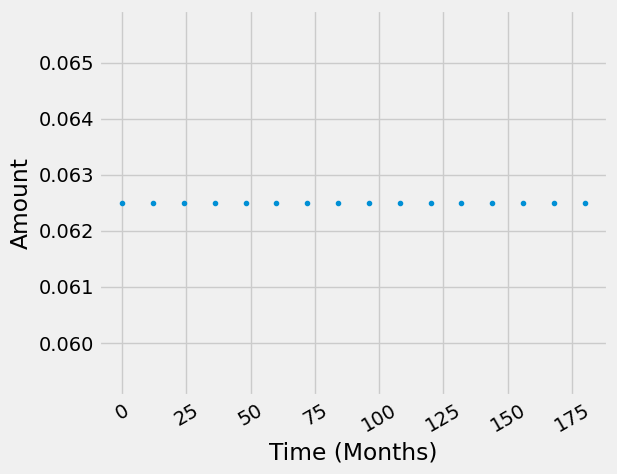

In [6]:
driving = bd.get_node(database="foreground", name="driving an electric vehicle")
ev_to_driving = next(exc for exc in driving.technosphere() if exc.input["name"] == "electricity")

print(ev_to_driving["temporal_distribution"].date) # original resolution was timedelta64[M], which gets converted to seconds
print(ev_to_driving["temporal_distribution"].amount)
print(ev_to_driving["temporal_distribution"].date.dtype)

ev_to_driving["temporal_distribution"].graph(resolution="M")

In [7]:
ev_to_driving["temporal_distribution"]

TemporalDistribution instance with 16 values and total: 1

### Add a characterization method

Finally, we need some characterization method. Again, this is just a simple made-up one:

In [8]:
bd.Method(("GWP", "example")).write(
    [
        (("biosphere", "CO2"), 1),
    ]
)

## LCA using `bw_timex`


Now that the data is set up, we can get startet with the actual time-explicit LCA. As usual, we need to select a method first:

In [9]:
method = ("GWP", "example")

`bw_timex` needs to know the representative time of the databases:

In [10]:
from datetime import datetime

database_dates = {
    "background_2020": datetime.strptime("2020", "%Y"),
    "background_2030": datetime.strptime("2030", "%Y"),
    "background_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",  # flag databases that should be temporally distributed with "dynamic"
}

Now, we can instantiate a `TimexLCA`. It's structure is similar to a normal `bw2calc.LCA`, but with the additional argument `database_dates`.

Not sure about the required inputs? Check the documentation using `?`. All our classes and methods have docstrings!

In [11]:
from bw_timex import TimexLCA

Let's create a `TimexLCA` object for our EV life cycle:

In [12]:
driving = bd.get_node(database="foreground", code="driving", name="driving an electric vehicle", unit="transport over an ev lifetime")

In [ ]:
# intialize the TimexLCA object with the functional unit, method, and database dates
tlca = TimexLCA({driving: 1}, method, database_dates)
# build the timeline with a temporal grouping of "month"
tlca.build_timeline(temporal_grouping="month")
# calculate the time-explicit LCI
tlca.lci()

2026-06-25 17:01:01.438 | INFO     | bw_timex.timex_lca:__init__:115 - Initializing TimexLCA object...
2026-06-25 17:01:01.438 | INFO     | bw_timex.timex_lca:__init__:131 - Calculating base LCA...
2026-06-25 17:01:01.447 | INFO     | bw_timex.timex_lca:__init__:148 - Collecting node infos...


Let's check the dynamic invenrotry in a human readale format

In [39]:
tlca.create_labelled_dynamic_inventory_dataframe()

,date,amount,flow,activity
0,2025-01-01,13671.000000,carbon dioxide,glider
1,2026-01-01,6090.000000,carbon dioxide,battery
2,2026-01-01,3480.000000,carbon dioxide,powertrain
3,2026-01-01,1827.000000,carbon dioxide,glider
5,2027-01-01,3402.000000,carbon dioxide,glider
4,2027-01-01,632.812500,carbon dioxide,electricity
6,2028-01-01,585.937500,carbon dioxide,electricity
7,2029-01-01,539.062500,carbon dioxide,electricity
8,2030-01-01,492.187500,carbon dioxide,electricity
9,2031-01-01,452.343750,carbon dioxide,electricity


Now we can do all further analysis as detailed in the other example notebook [example_electric_vehicle_standalone](./example_electric_vehicle_standalone.ipynb). Below you just find the quick calculations. For the full dynamic characterization please see the linked notebook.

In [ ]:
# Static LCIA from time-explicit LCI
tlca.static_lcia()
tlca.static_score   #kg CO2-eq

34122.72503901273

At this point, we can already compare these time-explicit results to the results of an "ordinary", completely static LCA. These already exist within the TimexLCA class, originally to set the priorities for the graph traversal:

In [ ]:
# compare to fully static non time-explicit LCIA score
tlca.base_lca.score

28089.199999794364